In [14]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
file = uproot.open("../../Datos/BEhistos_year123456.root")
file.keys()

['hbea_123456y_D0;1',
 'hbea_123456y_D1;1',
 'hbea_123456y_D2;1',
 'hbea_123456y_D3;1',
 'hbea_123456y_D4;1',
 'hbea_123456y_D5;1',
 'hbea_123456y_D6;1',
 'hbea_123456y_D7;1',
 'hbea_123456y_D8;1',
 'hbea_123456y;1']

In [15]:
def carga_datos_hist(path,name):
    file = uproot.open(path)
    file.keys()
    x=file[name].axis().centers()
    y=file[name].values()
    s=file[name].errors()
    return x,y,s



Imprimimos los histogramas con *matplotlib*

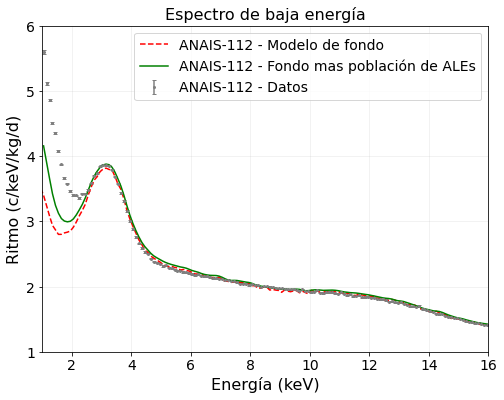

In [70]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator



Ritmox,Ritmoy,Ritmos=carga_datos_hist("../../Datos/BEhistos_year123456.root","hbea_123456y")

Fondox,Fondoy,Fondos=carga_datos_hist("../../Datos/backgroundModel_single_y123456.root","h")

ALEx,ALEy,ALEs=carga_datos_hist("../../Datos/backgroundModel_single_y123456_conANOD.root","h")


LABEL_SIZE = 16
TICK_SIZE  = 14

plt.figure(figsize=(8, 6))

ax = plt.subplot()

#ax.scatter(Ritmox,Ritmoy,label="asd")

ax.errorbar(Ritmox, Ritmoy, Ritmos, fmt="o", color="gray",
            markersize=2, capsize=2, label="ANAIS-112 - Datos",alpha=1)

ax.plot(Fondox,Fondoy,c="red", linestyle="--",label="ANAIS-112 - Modelo de fondo")
ax.plot(ALEx,ALEy,c="green",label="ANAIS-112 - Fondo mas población de ALEs")
ax.set_xlim(1,16)
ax.set_ylim(1,6)
ax.legend(fontsize=14)
ax.yaxis.set_major_locator(MultipleLocator(1))  # un tick cada 1 unidad
ax.set_title(r'Espectro de baja energía',fontsize=16)
ax.set_ylabel(r'Ritmo (c/keV/kg/d)',fontsize=LABEL_SIZE)
ax.set_xlabel(r'Energía (keV)',fontsize=LABEL_SIZE)

ax.grid(which='both', linestyle='-', alpha=0.2)
ax.tick_params(axis='both', which='both', labelsize=TICK_SIZE)

plt.savefig("Modelosdefondo.pdf", dpi=150, facecolor='white',bbox_inches='tight')
